### DogeCoin Price Preddiction using RandomForestRegressor in sklearn.

##### 1. Importing Libraries

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

##### 1. Importing Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/18-Dogecoin%20Price%20Prediction/DOGE-USD.csv

--2026-03-09 10:38:52--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/18-Dogecoin%20Price%20Prediction/DOGE-USD.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115561 (113K) [text/plain]
Saving to: ‘DOGE-USD.csv’

DOGE-USD.csv        100%[===================>] 112.85K  --.-KB/s    in 0.06s   

2026-03-09 10:38:53 (1.74 MB/s) - ‘DOGE-USD.csv’ saved [115561/115561]



In [22]:
df = pd.read_csv('DOGE-USD.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


In [4]:
# Let's check the correlation
df.corr(method='pearson' ,numeric_only=True)

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1761 non-null   object 
 1   Open       1760 non-null   float64
 2   High       1760 non-null   float64
 3   Low        1760 non-null   float64
 4   Close      1760 non-null   float64
 5   Adj Close  1760 non-null   float64
 6   Volume     1760 non-null   float64
dtypes: float64(6), object(1)
memory usage: 96.4+ KB


In [23]:
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format = True)
df.set_index('Date', inplace=True)
df.isnull().any()

/tmp/ipykernel_659/881756047.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format = True)


,0
Open,True
High,True
Low,True
Close,True
Adj Close,True
Volume,True


In [24]:
df.isnull().sum()

,0
Open,1
High,1
Low,1
Close,1
Adj Close,1
Volume,1


In [8]:
df.dropna()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0
...,...,...,...,...,...,...,...
1755,2022-08-30,0.063899,0.064408,0.060550,0.061525,0.061525,328934727.0
1756,2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
1757,2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0
1758,2022-09-02,0.062372,0.062712,0.060947,0.061635,0.061635,273453013.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1761 entries, 2017-11-09 to 2022-09-04
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1760 non-null   float64
 1   High       1760 non-null   float64
 2   Low        1760 non-null   float64
 3   Close      1760 non-null   float64
 4   Adj Close  1760 non-null   float64
 5   Volume     1760 non-null   float64
dtypes: float64(6)
memory usage: 96.3 KB


In [26]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


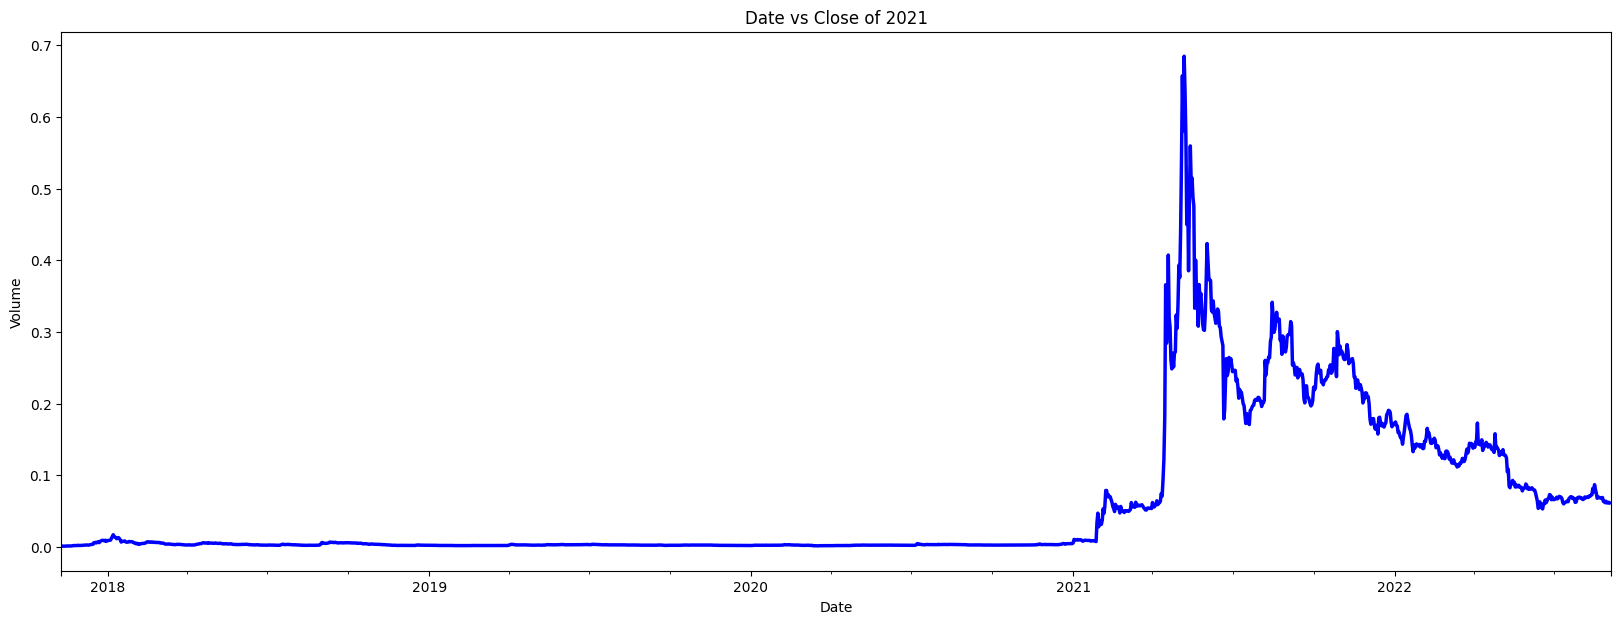

In [27]:
plt.figure(figsize=(20,7))
x = df.groupby('Date')['Close'].mean()
x.plot(linewidth = 2.5, color='b')
plt.title("Date vs Close of 2021")
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [28]:
df["gap"] = (df["High"] - df["Low"]) * df["Volume"]
df["y"] = df["High"] / df["Volume"]
df["z"] = df["Low"] / df["Volume"]
df["a"] = df["High"] / df["Low"]
df["b"] = (df["High"] / df["Low"]) * df["Volume"]
abs(df.corr()["Close"].sort_values(ascending=False))

,Close
Close,1.000000
Adj Close,1.000000
High,0.995104
Low,0.994575
Open,0.992514
Volume,0.588678
b,0.456479
gap,0.383333
a,0.172057
z,0.063251


In [29]:
df = df[["Close", "Volume", "gap", "a", "b"]]
df.head()

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


In [30]:
df2 = df.tail(30)
train = df2[:11]
test = df2[-19:]

print(train.shape, test.shape)

(11, 5) (19, 5)


##### 2. Model Development

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Remove missing values before modeling
train_rf = train.dropna().copy()
test_rf = test.dropna().copy()

In [35]:
# Prepare train/test sets
X_train = train_rf.drop("Close", axis=1)
y_train = train_rf["Close"]
X_test = test_rf.drop("Close", axis=1)
y_test = test_rf["Close"]

In [36]:
# Train RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=300, random_state=42)

In [37]:
# Predictions and evaluation
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Train rows used: {len(train_rf)}")
print(f"Test rows used:  {len(test_rf)}")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.6f}")

Train rows used: 11
Test rows used:  18
MAE:  0.005720
MSE:  0.000040
RMSE: 0.006329
R2:   -0.601202


In [40]:
# Compare actual vs predicted values
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}, index=y_test.index)
display(results_df.head(10))

,Actual,Predicted
Date,,
2022-08-17,0.080154,0.074207
2022-08-18,0.075079,0.071334
2022-08-19,0.067939,0.074633
2022-08-20,0.069540,0.070938
2022-08-21,0.069448,0.071845
2022-08-22,0.068391,0.071195
2022-08-23,0.068770,0.070788
2022-08-24,0.067990,0.071399
2022-08-25,0.069094,0.071137


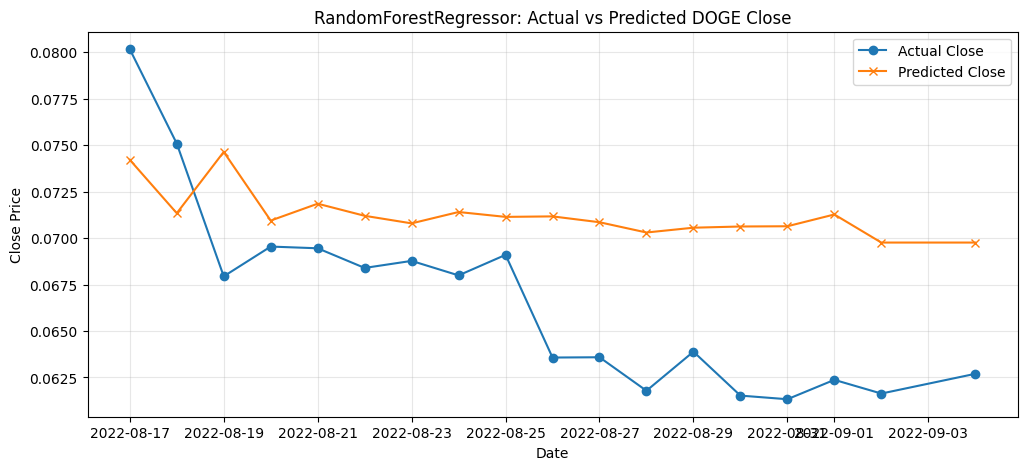

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(results_df.index, results_df["Actual"], label="Actual Close", marker="o")
plt.plot(results_df.index, results_df["Predicted"], label="Predicted Close", marker="x")
plt.title("RandomForestRegressor: Actual vs Predicted DOGE Close")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature Importance:")
display(importance)


Feature Importance:


,0
a,0.283854
Volume,0.255479
gap,0.235184
b,0.225483
